# Scaffold hopping by holistic molecular representation in drug design

#### Francesca Grisoni,* Gisbert Schneider

ETH Zurich, Department of Chemistry and Applied Biosciences, RETHINK, Vladimir-Prelog-Weg 4, 8093, Zurich, Switzerland. <div>
*Corresponding author: francesca.grisoni@pharma.ethz.ch 


## Table of Contents
1. [Preliminary steps](#preliminary)
2. [Molecule import and pre-treatment](#import)
3. [WHALES descriptors](#whales) <div>
    a. [*WHALES calculation*](#calculation) <div>
    b. [*Descriptor scaling*](#scaling)
4. [Virtual screening](#vs)<div>
    a. [*Similarity calculation*](#similarity)<div>
    b. [*Identification of top hits*](#tophits)<div>
5. [Scaffold analysis](#scaffold)<div>
    a. [*Template scaffold*](#templatescaffold)<div>
    b. [*Library scaffold diversity*](#libraryscaffold)<div>
    c. [*Scaffold diversity of the top hits*](#tophitsscaffold)<div>
6. [How to cite](#cite) 

# Import of necessary packages <a name="preliminary"></a>

Here you will find all of the necessary packages that will be used in this Jupyter Notebook. No worries, they should all be installed already in your virtual environment!

In [ ]:
# chemistry toolkits
# WHALES-related code
from __future__ import annotations

import numpy as np

# for data analysis and plotting
import pandas as pd
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import (
    AllChem,
    Draw,  # for molecule depiction
)
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.metrics.pairwise import euclidean_distances

import whales

# Molecule import and pre-treatment <a name="import"></a>

## Template molecule

Import and visualization of galantamine, starting from SMILES

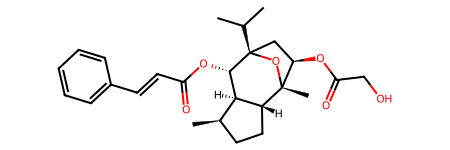

In [8]:
# import template from SMILES
template = Chem.MolFromSmiles(
    "C[C@@H]1CC[C@@H]2[C@@H]1[C@@H]([C@@]3(C[C@H]([C@]2(O3)C)OC(=O)CO)C(C)C)OC(=O)/C=C/c4ccccc4"
)  # imports from SMILES
# add 2D coordinates for visualization
err = AllChem.Compute2DCoords(template)
template

Prepare the molecule, by checking for errors and optimizing the 3D conformation

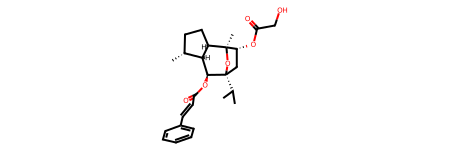

In [9]:
mol = whales.prepare_mol(template)
mol

Inspect the partial charges that will be used for WHALES calculation

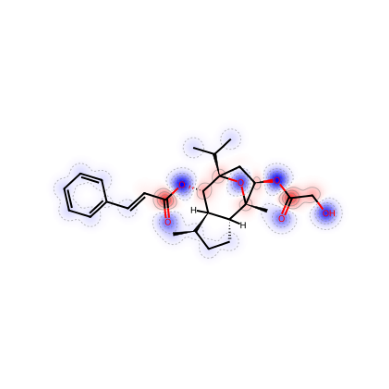

In [10]:
whales.do_map(template, lab_atom=True)

In [11]:
writer = Chem.rdmolfiles.SDWriter("out.sdf")
writer.write(mol)

## Compound library

Import and prepare library

In [12]:
# set the path to the sdf file for input and output
input_filename = "data/library.sdf"
vs_library_2D = Chem.SDMolSupplier(input_filename)  # conserved for 2D representations # noqa: N816
vs_library = whales.prepare_mol_from_sdf(
    input_filename
)  # computes 3D geometry from a specified sdf file

Molecule: 0
Molecule: 50
Molecule: 100
Molecule: 150
Molecule: 200
Molecule: 250
Molecule: 300
Molecule: 350
Molecule: 400
Molecule: 450
Molecule: 500
Molecule: 550
Molecule: 600
Molecule: 650
Molecule: 700
Molecule: 750
Molecule: 800
Molecule: 850
Molecule: 900
Molecule: 950


Visually inspect the database after geometry optimization

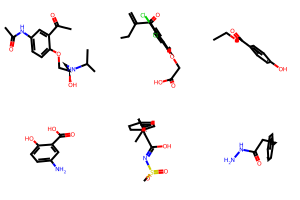

In [28]:
# Visualize the first 6 molecules of the database after geometry optimization
number_mol = 6  # number of molecules to inspect
Draw.MolsToGridImage(
    vs_library[:number_mol],
    molsPerRow=3,
    subImgSize=(100, 100),
    legends=[x.GetProp("_Name") for x in vs_library[:number_mol]],
)

# WHALES descriptors <a name="whales"></a>

## Descriptors calculation <a name="calculation"></a>

Compute WHALES descriptors for the template molecule

In [14]:
# compute descriptors as an array
whales_template, lab = whales.whales_from_mol(template)
# convert the arrays into a pandas dataframe
df_whales_template = pd.DataFrame(
    whales_template.reshape(-1, len(whales_template)), index=["template"], columns=lab
)
df_whales_template

,R_0,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,R_9,...,IR_1,IR_2,IR_3,IR_4,IR_5,IR_6,IR_7,IR_8,IR_9,IR_10
template,-2.202,-1.59,-1.413,-1.17,-0.953,-0.723,-0.479,0.07,0.392,0.481,...,-0.088,-0.054,-0.038,-0.029,-0.022,-0.017,0.018,0.059,0.147,0.226


Compute WHALES for the virtual screening library

In [15]:
whales_library = []
for mol in vs_library:  # runs over the library and updates WHALES
    whales_temp, lab = whales.whales_from_mol(mol)
    whales_library.append(whales_temp)
# convert the arrays into a pandas dataframe
df_whales_library = pd.DataFrame(whales_library, columns=lab)
df_whales_library.head()  # library preview

,R_0,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,R_9,...,IR_1,IR_2,IR_3,IR_4,IR_5,IR_6,IR_7,IR_8,IR_9,IR_10
0,-3.727,-1.563,-1.275,-0.987,-0.499,-0.424,0.374,0.534,0.866,1.168,...,-0.165,-0.143,-0.094,-0.063,-0.020,0.034,0.062,0.091,0.153,0.176
1,-4.011,-2.449,-1.890,-1.469,-1.255,-0.725,-0.595,0.431,0.635,0.755,...,-0.143,-0.111,-0.106,-0.080,-0.051,-0.014,0.116,0.198,0.265,0.507
2,-21.571,-1.259,-0.977,-0.960,-0.907,-0.788,-0.726,-0.040,0.372,0.485,...,-0.116,-0.103,-0.095,-0.084,-0.051,-0.023,0.033,0.084,0.180,0.447
3,-1.804,-1.409,-1.120,-1.075,-1.061,-0.991,-0.900,0.463,0.513,0.567,...,-0.351,-0.287,-0.204,-0.163,-0.092,-0.080,0.045,0.458,0.471,0.621
4,-3.060,-2.078,-1.765,-1.497,-1.182,-0.925,-0.854,-0.740,-0.188,0.744,...,-0.407,-0.195,-0.162,-0.134,-0.089,-0.084,-0.039,0.037,0.172,0.814


## Descriptors scaling <a name="scaling"></a>

### Data visualization
Visualizing the raw descriptor values for the virtual screening library using a boxplot

<Axes: >

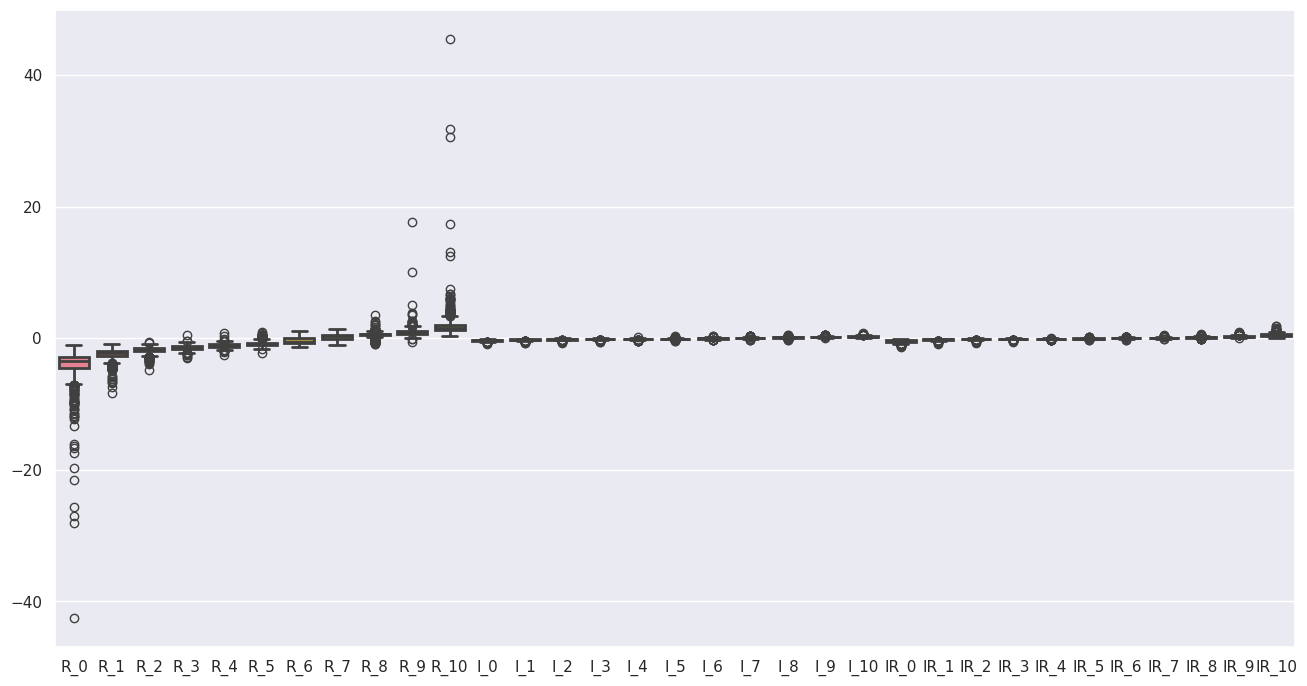

In [16]:
sns.set_theme(rc={"figure.figsize": (16, 8.27)})  # sets the size of the boxplot
sns.boxplot(data=df_whales_library, linewidth=2)

### Autoscaling

Virtual library scaling

In [17]:
aver = df_whales_library.mean()
sdv = df_whales_library.std()
df_whales_library_scaled = (df_whales_library - aver) / sdv
df_whales_library_scaled.to_csv("WHALES_after.csv")

Template scaling

In [18]:
df_whales_template_scaled = (df_whales_template - aver) / sdv
df_whales_template_scaled

,R_0,R_1,R_2,R_3,R_4,R_5,R_6,R_7,R_8,R_9,...,IR_1,IR_2,IR_3,IR_4,IR_5,IR_6,IR_7,IR_8,IR_9,IR_10
template,0.697565,1.054485,0.830449,0.720473,0.598645,0.283188,-0.198469,-0.243805,-0.536189,-0.656294,...,1.388414,1.414494,1.370631,1.217646,0.718805,-0.14104,-0.588689,-1.110823,-1.098803,-1.265489


### Data visualization
Visualizing the descriptor values for the virtual screening library after autoscaling


<Axes: >

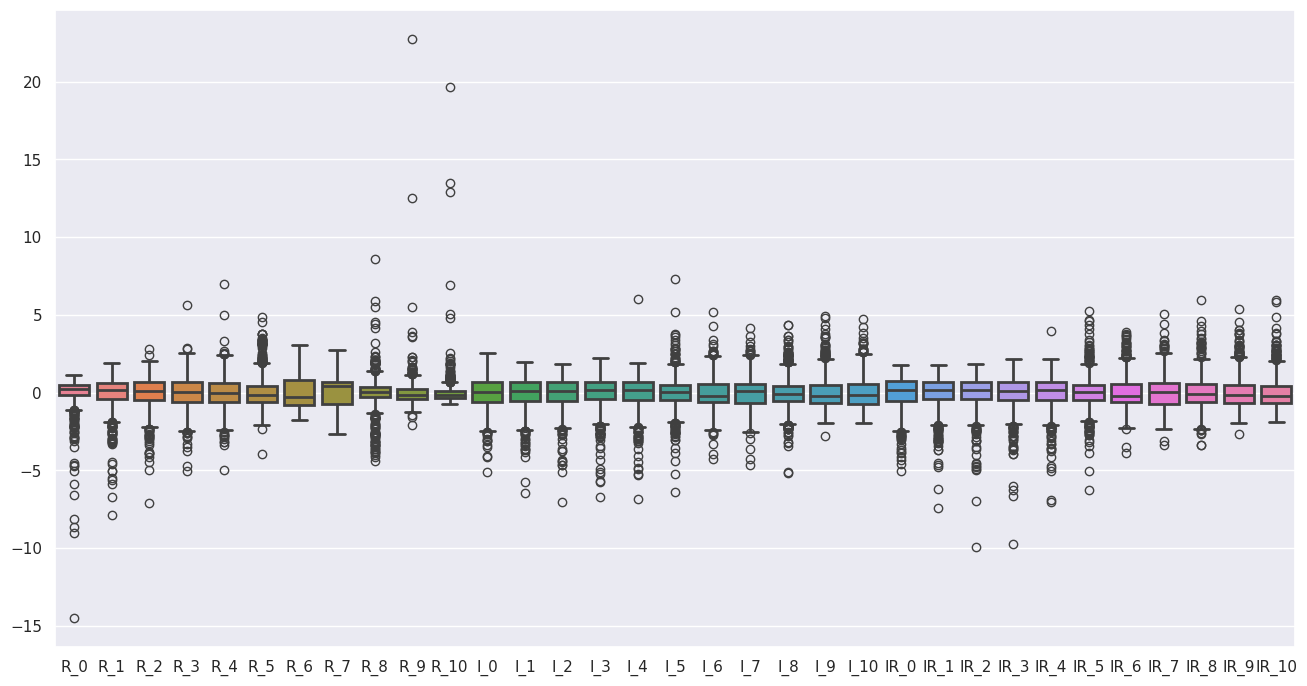

In [19]:
sns.set_theme(rc={"figure.figsize": (16, 8.27)})
sns.boxplot(data=df_whales_library_scaled, linewidth=2)

# Virtual screening <a name="vs"></a>

## Similarity calculation <a name="similarity"></a>

In [20]:
# compute Euclidean distance
D = euclidean_distances(df_whales_template_scaled, df_whales_library_scaled)

## Identification of top hits <a name="tophits"></a>
Selection of the 10 closest compounds based on the computed distance on WHALES

In [ ]:
# sorting based on distance
sort_index = np.argsort(D)  # index for sorting according to D
D_neig = D[:, sort_index]  # sorted distance

In [22]:
# selection of the 10 closest compounds
k = 10  # number of compounds to choose
neighbor_ID = sort_index[:, 0:k]  # noqa: N816
neighbor_ID

array([[160, 940, 869, 136, 569, 119, 116,  87, 631, 335]])

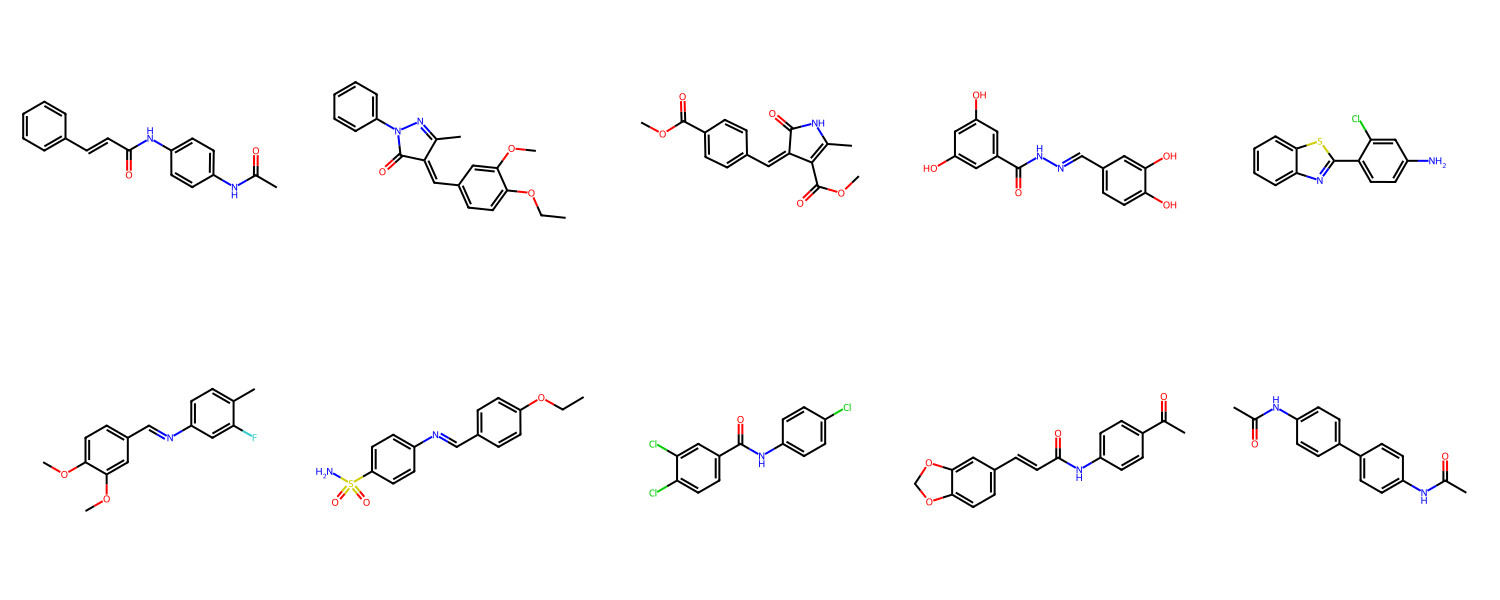

In [ ]:
# display of the 10 closest compounds
hits = []
smiles_hits = []
for j in np.nditer(neighbor_ID):
    hits.append(vs_library_2D[int(j)])
    smiles_hits.append(Chem.MolToSmiles(mol))

# Visualize the first 10 molecules of the database after geometry optimization
number_mol = 10  # number of molecules to inspect
Draw.MolsToGridImage(
    hits[: number_mol + 1],
    molsPerRow=5,
    subImgSize=(300, 300),
    legends=[x.GetProp("_Name") for x in hits[: number_mol + 1]],
)

# Scaffold analysis <a name="scaffold"></a>

## Template scaffold <a name="templatescaffold"></a>

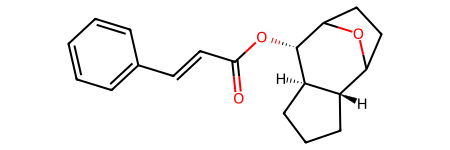

In [24]:
core = MurckoScaffold.GetScaffoldForMol(template)
core

## Scaffold diversity of the virtual screening library

Compute the Bemis-Murcko scaffolds for the virtual screening library

In [ ]:
# generates an empty supplier to contain the computed scaffold
scaffold_vs = [MurckoScaffold.GetScaffoldForMol(mol) for mol in vs_library_2D]

Preview of the scaffolds (4 for display)

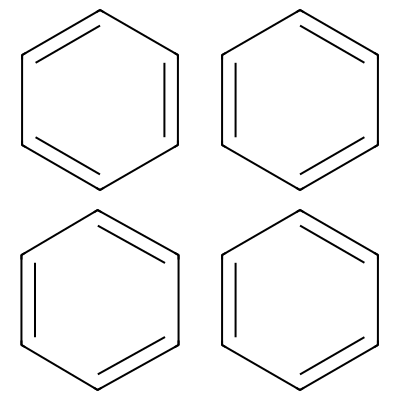

In [26]:
# 4 scaffolds are displayed
k = 4
Draw.MolsToGridImage(
    scaffold_vs[:k],
    molsPerRow=2,
    subImgSize=(200, 200),
    legends=[x.GetProp("_Name") for x in scaffold_vs[:k]],
)

Most frequently recurring scaffolds in the virtual screening library

In [30]:
freq_scaffolds_library = whales.frequent_scaffolds(
    vs_library_2D
)  # contains the list of the (unique) scaffolds, sorted by number

Display the four most occurring scaffolds

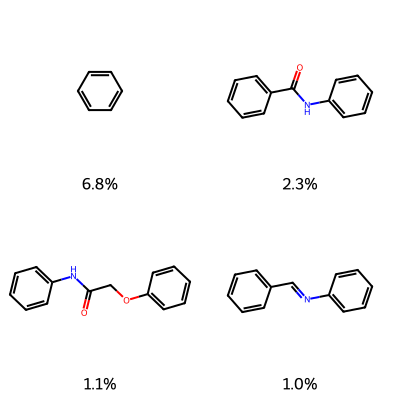

In [31]:
k = 4
Draw.MolsToGridImage(
    freq_scaffolds_library[:k],
    molsPerRow=2,
    subImgSize=(200, 200),
    legends=[x.GetProp("_Name") for x in freq_scaffolds_library[:k]],
)

Computes the relative scaffold diversity of the library

In [32]:
SD_rel = len(freq_scaffolds_library) / len(vs_library) * 100
print(SD_rel)

54.2


## Top hits scaffolds

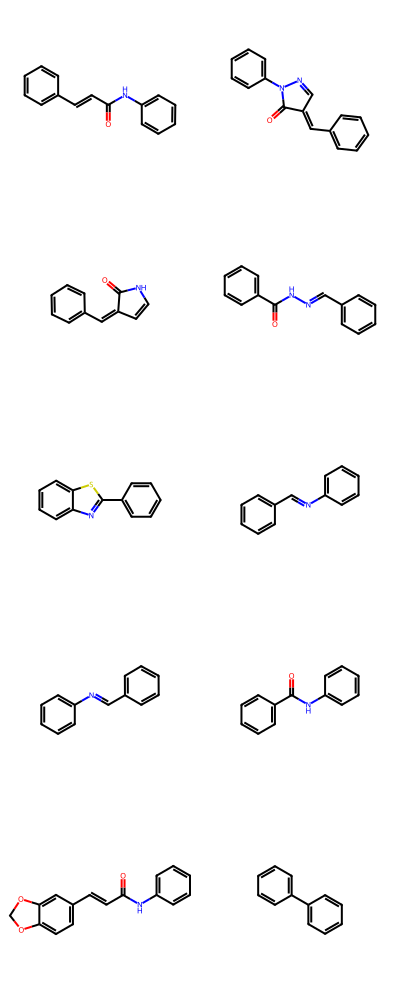

In [ ]:
scaffold_hits = [MurckoScaffold.GetScaffoldForMol(mol) for mol in hits]

Draw.MolsToGridImage(
    scaffold_hits[:10],
    molsPerRow=2,
    subImgSize=(200, 200),
    legends=[x.GetProp("_Name") for x in scaffold_hits[:10]],
)

Computes the frequent scaffolds and the scaffold diversity

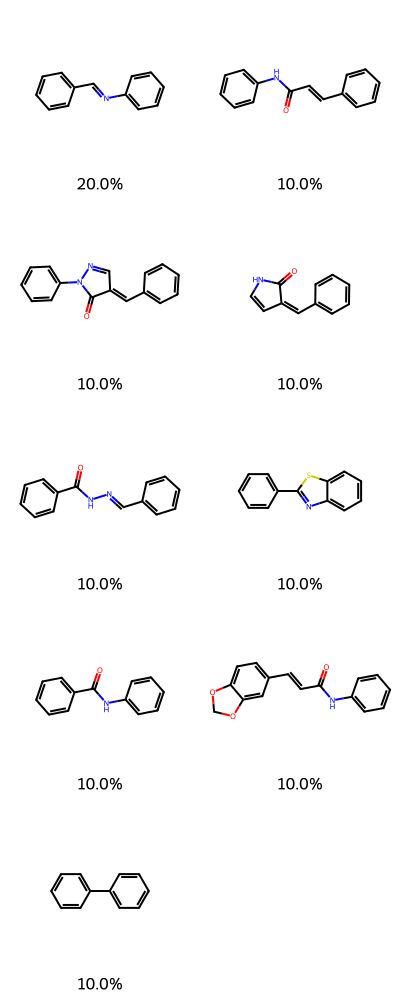

In [34]:
freq_scaffolds_hits = whales.frequent_scaffolds(
    hits
)  # contains the list of the (unique) scaffolds, sorted by number
k = len(freq_scaffolds_hits)  # display all scaffolds
Draw.MolsToGridImage(
    freq_scaffolds_hits[:k],
    molsPerRow=2,
    subImgSize=(200, 200),
    legends=[x.GetProp("_Name") for x in freq_scaffolds_hits[:k]],
)

In [35]:
SD_rel = len(freq_scaffolds_hits) / len(hits) * 100
print(SD_rel)

90.0
